Topics


*   Matrix multiplication (Part 1)
*   Comparison of different GNN operators: Reuse of Pytorch Geometric Functions (Part 3)
*   Comparison of different GNN operators: Breaking down Graph Convolution and Graph Attention (Part 4)



# Part 1: Matrix Multiplication

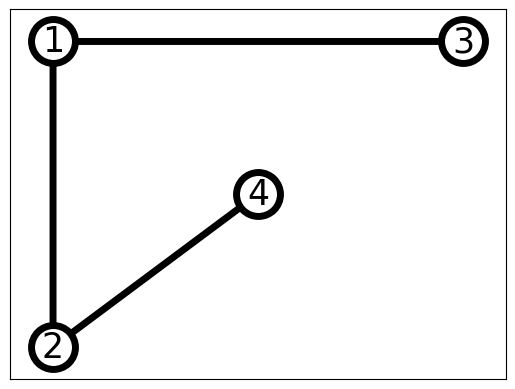

In [152]:
import networkx as nx
G = nx.Graph() #nx.Digraph()
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edge(4, 2)

pos = {1: (0, 1), 2: (0, 0), 3: (1, 1), 4: (0.5, 0.5)}

options = {
    "font_size": 25,
    "node_size": 1000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,

}
nx.draw_networkx(G, pos, **options, arrows=True)

In [153]:
A = nx.adjacency_matrix(G)
A.toarray()

array([[0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 1, 0, 0]])

In [154]:
from scipy.sparse import coo_array
import numpy as np

u = coo_array(A.toarray()).coords
np.asarray(u)

array([[0, 0, 1, 1, 2, 3],
       [1, 2, 0, 3, 0, 1]], dtype=int32)

In [155]:
F = [5, 8, 3, 1]

In [156]:
import torch
import numpy as np

F1 = torch.Tensor(np.array(F))

A1 = torch.Tensor(np.array(A.toarray()))

F1, A1, F1.shape, A1.shape

(tensor([5., 8., 3., 1.]),
 tensor([[0., 1., 1., 0.],
         [1., 0., 0., 1.],
         [1., 0., 0., 0.],
         [0., 1., 0., 0.]]),
 torch.Size([4]),
 torch.Size([4, 4]))

Matrix Multiplication

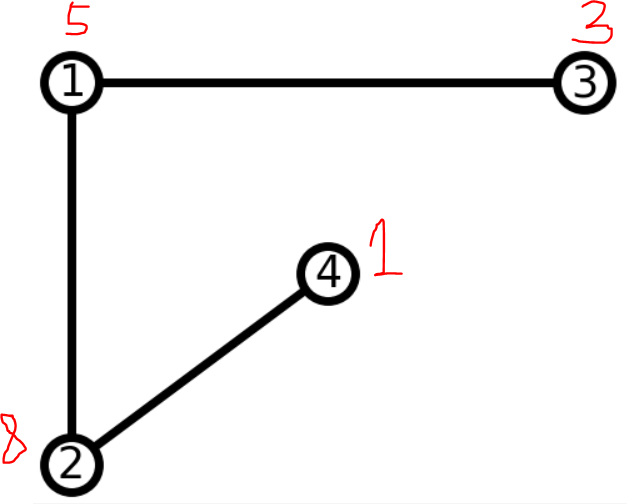

In [157]:
torch.matmul(F1, A1) # features aggregation of neighbouring nodes as matrix multiplication

tensor([11.,  6.,  5.,  8.])

In [158]:
F1 @ A1 # @ is a shortcut für torch.matmul in Pytorch

tensor([11.,  6.,  5.,  8.])

In [159]:
A1.size(0) # number of nodes

4

In [160]:
I = torch.eye(A1.size(0))
I

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])

In [161]:
A2 = A1 + I
A2

tensor([[1., 1., 1., 0.],
        [1., 1., 0., 1.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.]])

In [162]:
F1 @ A2

tensor([16., 14.,  8.,  9.])

Degree Matrix: How many edges per node

In [163]:
degree = A1.sum(1)
degree

tensor([2., 2., 1., 1.])

In [164]:
G.degree()

DegreeView({1: 2, 2: 2, 3: 1, 4: 1})

In [165]:
D = torch.diag(degree) # diagonal degree matrix (torch diag constructs a square matrix with input as diagonal)
D, D.shape

(tensor([[2., 0., 0., 0.],
         [0., 2., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]]),
 torch.Size([4, 4]))

In [15]:
A2, A2.shape

(tensor([[1., 1., 1., 0.],
         [1., 1., 0., 1.],
         [1., 0., 1., 0.],
         [0., 1., 0., 1.]]),
 torch.Size([4, 4]))

Some additional reminders about matrix multiplication

*   matrix multiplication is NOT commutative (changing the order or the matrices changes the result); matrix addition IS commutative
*   for matrix multiplication to work the dimension 2 of matrix 1 and the dimension 1 of matrix 2 must be match



In [166]:
D @ A2

tensor([[2., 2., 2., 0.],
        [2., 2., 0., 2.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.]])

In [167]:
A2 @ D

tensor([[2., 2., 1., 0.],
        [2., 2., 0., 1.],
        [2., 0., 1., 0.],
        [0., 2., 0., 1.]])

In [18]:
degree, torch.pow(degree, -0.5)

(tensor([2., 2., 1., 1.]), tensor([0.7071, 0.7071, 1.0000, 1.0000]))

In [19]:
D_inv_sqrt = torch.diag(torch.pow(degree, -0.5))
D_inv_sqrt

tensor([[0.7071, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.7071, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.0000]])

# Part 2: Graph Data Preparation



In [20]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00


In [168]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# List of European countries and their land borders (based on CIA World Factbook and Wikipedia)
# Note: Generated with ChatGPT, checked afterwards for correctness.
borders = {
    "Albania": ["Greece", "Kosovo", "Montenegro", "North Macedonia"],
    "Andorra": ["France", "Spain"],
    "Austria": ["Czechia", "Germany", "Hungary", "Italy", "Liechtenstein", "Slovakia", "Slovenia", "Switzerland"],
    "Belarus": ["Latvia", "Lithuania", "Poland", "Russia", "Ukraine"],
    "Belgium": ["France", "Germany", "Luxembourg", "Netherlands"],
    "Bosnia and Herzegovina": ["Croatia", "Montenegro", "Serbia"],
    "Bulgaria": ["Greece", "North Macedonia", "Romania", "Serbia", "Turkey"],
    "Croatia": ["Bosnia and Herzegovina", "Hungary", "Montenegro", "Serbia", "Slovenia"],
    "Czechia": ["Austria", "Germany", "Poland", "Slovakia"],
    "Denmark": ["Germany"],
    "Estonia": ["Latvia", "Russia"],
    "Finland": ["Norway", "Russia", "Sweden"],
    "France": ["Andorra", "Belgium", "Germany", "Italy", "Luxembourg", "Monaco", "Spain", "Switzerland"],
    "Germany": ["Austria", "Belgium", "Czechia", "Denmark", "France", "Luxembourg", "Netherlands", "Poland", "Switzerland"],
    "Gibraltar": ["Spain"],
    "Greece": ["Albania", "Bulgaria", "North Macedonia", "Turkey"],
    "Hungary": ["Austria", "Croatia", "Romania", "Serbia", "Slovakia", "Slovenia", "Ukraine"],
    "Iceland": [],
    "Ireland": ["United Kingdom"],
    "Italy": ["Austria", "France", "San Marino", "Slovenia", "Switzerland", "Vatican City"],
    "Kosovo": ["Albania", "Montenegro", "North Macedonia", "Serbia"],
    "Latvia": ["Belarus", "Estonia", "Lithuania", "Russia"],
    "Liechtenstein": ["Austria", "Switzerland"],
    "Lithuania": ["Belarus", "Latvia", "Poland", "Russia"],
    "Luxembourg": ["Belgium", "France", "Germany"],
    "Malta": [],
    "Moldova": ["Romania", "Ukraine"],
    "Monaco": ["France"],
    "Montenegro": ["Albania", "Bosnia and Herzegovina", "Croatia", "Kosovo", "Serbia"],
    "Netherlands": ["Belgium", "Germany"],
    "North Macedonia": ["Albania", "Bulgaria", "Greece", "Kosovo", "Serbia"],
    "Norway": ["Finland", "Russia", "Sweden"],
    "Poland": ["Belarus", "Czechia", "Germany", "Lithuania", "Russia", "Slovakia", "Ukraine"],
    "Portugal": ["Spain"],
    "Romania": ["Bulgaria", "Hungary", "Moldova", "Serbia", "Ukraine"],
    "Russia": ["Belarus", "Estonia", "Finland", "Latvia", "Lithuania", "Norway", "Poland", "Ukraine"],
    "San Marino": ["Italy"],
    "Serbia": ["Bosnia and Herzegovina", "Bulgaria", "Croatia", "Hungary", "Kosovo", "Montenegro", "North Macedonia", "Romania"],
    "Slovakia": ["Austria", "Czechia", "Hungary", "Poland", "Ukraine"],
    "Slovenia": ["Austria", "Croatia", "Hungary", "Italy"],
    "Spain": ["Andorra", "France", "Gibraltar", "Portugal"],
    "Sweden": ["Finland", "Norway"],
    "Switzerland": ["Austria", "France", "Germany", "Italy", "Liechtenstein"],
    "Turkey": ["Bulgaria", "Greece"],
    "Ukraine": ["Belarus", "Hungary", "Moldova", "Poland", "Romania", "Russia", "Slovakia"],
    "United Kingdom": ["Ireland"],
    "Vatican City": ["Italy"]
}

# Create a sorted list of countries
countries = sorted(borders.keys())
print(len(countries))

# Initialize adjacency matrix
adj_matrix = pd.DataFrame(0, index=countries, columns=countries)

# Fill the matrix
for country, neighbors in borders.items():
    print(country, neighbors)
    for neighbor in neighbors:
        adj_matrix.loc[country, neighbor] = 1
        adj_matrix.loc[neighbor, country] = 1  # ensure symmetry

adj_matrix

47
Albania ['Greece', 'Kosovo', 'Montenegro', 'North Macedonia']
Andorra ['France', 'Spain']
Austria ['Czechia', 'Germany', 'Hungary', 'Italy', 'Liechtenstein', 'Slovakia', 'Slovenia', 'Switzerland']
Belarus ['Latvia', 'Lithuania', 'Poland', 'Russia', 'Ukraine']
Belgium ['France', 'Germany', 'Luxembourg', 'Netherlands']
Bosnia and Herzegovina ['Croatia', 'Montenegro', 'Serbia']
Bulgaria ['Greece', 'North Macedonia', 'Romania', 'Serbia', 'Turkey']
Croatia ['Bosnia and Herzegovina', 'Hungary', 'Montenegro', 'Serbia', 'Slovenia']
Czechia ['Austria', 'Germany', 'Poland', 'Slovakia']
Denmark ['Germany']
Estonia ['Latvia', 'Russia']
Finland ['Norway', 'Russia', 'Sweden']
France ['Andorra', 'Belgium', 'Germany', 'Italy', 'Luxembourg', 'Monaco', 'Spain', 'Switzerland']
Germany ['Austria', 'Belgium', 'Czechia', 'Denmark', 'France', 'Luxembourg', 'Netherlands', 'Poland', 'Switzerland']
Gibraltar ['Spain']
Greece ['Albania', 'Bulgaria', 'North Macedonia', 'Turkey']
Hungary ['Austria', 'Croatia', 

,Albania,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Czechia,Denmark,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Turkey,Ukraine,United Kingdom,Vatican City
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Andorra,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Austria,0,0,0,0,0,0,0,0,1,0,...,0,1,1,0,0,1,0,0,0,0
Belarus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
Belgium,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bosnia and Herzegovina,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
Bulgaria,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
Croatia,0,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
Czechia,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Denmark,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Values in millions
populations = {
    "Albania": 2.8,
    "Andorra": 0.08,
    "Austria": 9.1,
    "Belarus": 9.2,
    "Belgium": 11.6,
    "Bosnia and Herzegovina": 3.2,
    "Bulgaria": 6.5,
    "Croatia": 3.9,
    "Czechia": 10.8,
    "Denmark": 5.9,
    "Estonia": 1.3,
    "Finland": 5.5,
    "France": 68.0,
    "Germany": 83.3,
    "Greece": 10.1,
    "Hungary": 9.7,
    "Iceland": 0.39,
    "Ireland": 5.1,
    "Italy": 59.0,
    "Kosovo": 1.8,
    "Latvia": 1.9,
    "Liechtenstein": 0.04,
    "Lithuania": 2.6,
    "Luxembourg": 0.67,
    "Malta": 0.53,
    "Moldova": 2.6,
    "Monaco": 0.04,
    "Montenegro": 0.62,
    "Netherlands": 17.8,
    "North Macedonia": 2.0,
    "Norway": 5.5,
    "Poland": 37.5,
    "Portugal": 10.3,
    "Romania": 19.0,
    "Russia": 143.4,  # European part only; rough estimate
    "San Marino": 0.03,
    "Serbia": 6.6,
    "Slovakia": 5.4,
    "Slovenia": 2.1,
    "Spain": 47.6,
    "Sweden": 10.6,
    "Switzerland": 8.7,
    "Turkey": 85.0,  # European part only ~15 million; here, use total for simplicity
    "Ukraine": 35.0,  # Recent estimate post-conflict
    "United Kingdom": 68.2,
    "Vatican City": 0.0008,
    "Gibraltar": 0.03
}

In [169]:
def get_label(country):
    #print(country, " - ", borders[country])
    neighbors = borders[country]
    #print(populations[country])
    neighb_pops = 0
    for neighbor in neighbors:
        neighb_pops += populations[neighbor]
    #return int(neighb_pops + populations[country] > 150) # => message passing
    return int(neighb_pops > 150) # => conv and attention

In [170]:
get_label("France")

1

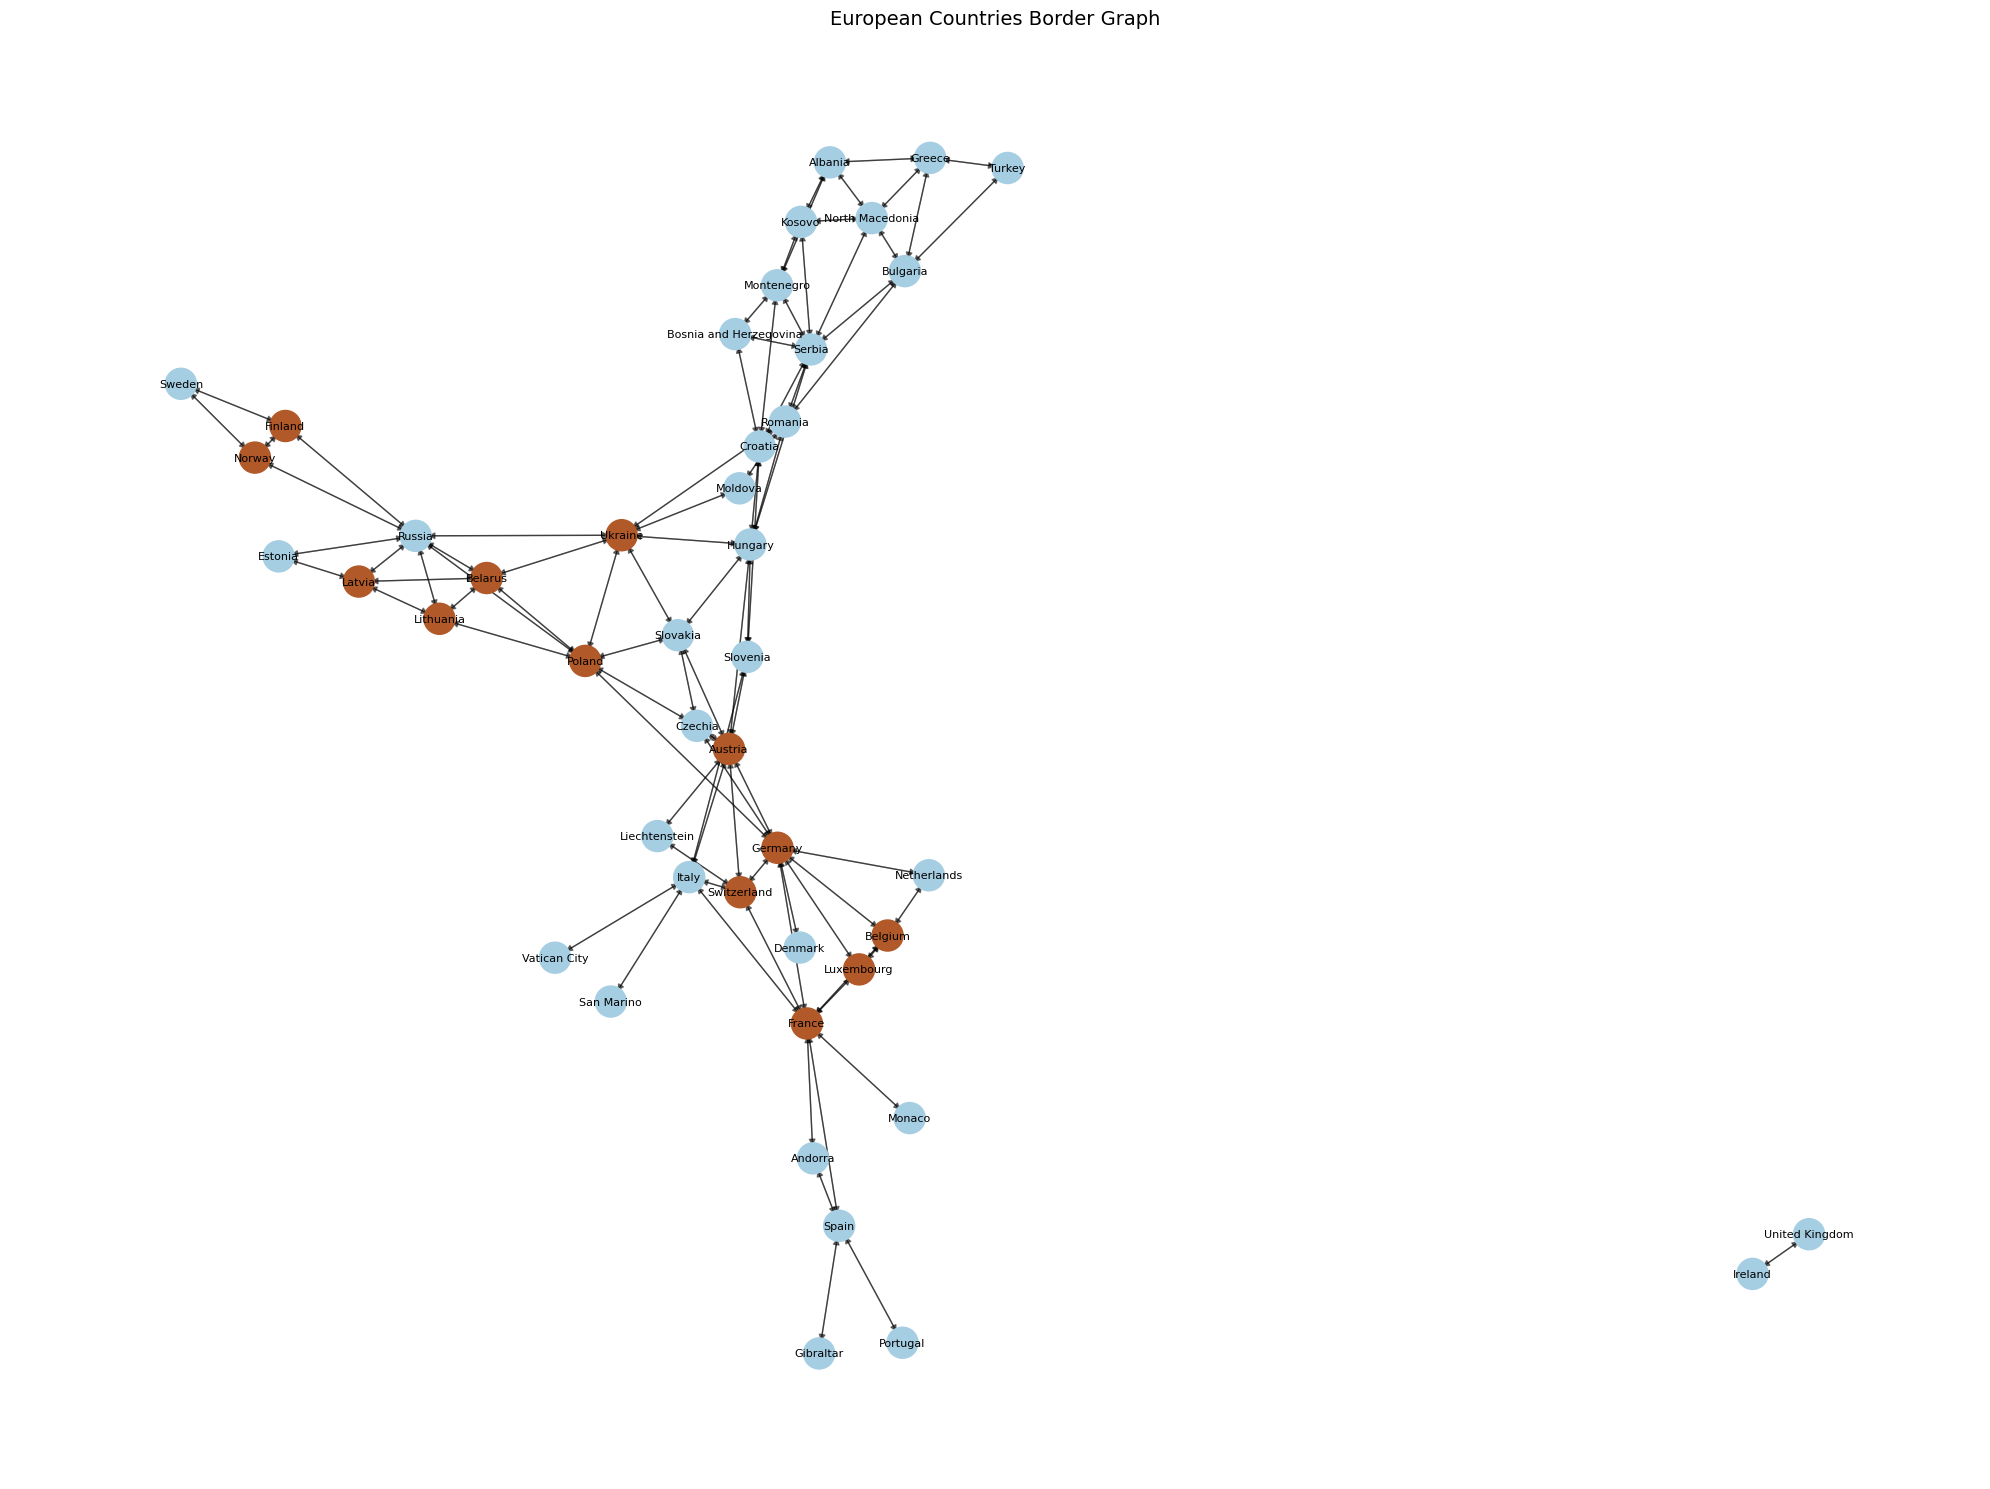

In [171]:
# Create graph visualization
G = nx.Graph()
for country, neighbors in borders.items():
    if len(neighbors) > 0: # only add countries that have a neighbour
        G.add_node(country, population=populations[country], label = get_label(country))
        for neighbor in neighbors:
            G.add_edge(country, neighbor)

G = nx.to_directed(G)

colors = [G.nodes[node]['label'] for node in list(G.nodes())]

# Draw the graph
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color = colors, cmap=plt.cm.Paired, node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("European Countries Border Graph", fontsize=14)
plt.axis("off")
plt.tight_layout()

In [26]:
CountryAdjacencyGraph = nx.convert_node_labels_to_integers(G, label_attribute='name')
print(CountryAdjacencyGraph.nodes(data=True))
training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]


[(0, {'population': 2.8, 'label': 0, 'name': 'Albania'}), (1, {'population': 10.1, 'label': 0, 'name': 'Greece'}), (2, {'population': 1.8, 'label': 0, 'name': 'Kosovo'}), (3, {'population': 0.62, 'label': 0, 'name': 'Montenegro'}), (4, {'population': 2.0, 'label': 0, 'name': 'North Macedonia'}), (5, {'population': 0.08, 'label': 0, 'name': 'Andorra'}), (6, {'population': 68.0, 'label': 1, 'name': 'France'}), (7, {'population': 47.6, 'label': 0, 'name': 'Spain'}), (8, {'population': 9.1, 'label': 1, 'name': 'Austria'}), (9, {'population': 10.8, 'label': 0, 'name': 'Czechia'}), (10, {'population': 83.3, 'label': 1, 'name': 'Germany'}), (11, {'population': 9.7, 'label': 0, 'name': 'Hungary'}), (12, {'population': 59.0, 'label': 0, 'name': 'Italy'}), (13, {'population': 0.04, 'label': 0, 'name': 'Liechtenstein'}), (14, {'population': 5.4, 'label': 0, 'name': 'Slovakia'}), (15, {'population': 2.1, 'label': 0, 'name': 'Slovenia'}), (16, {'population': 8.7, 'label': 1, 'name': 'Switzerland'})

# Part 3: Off-the-shelf layers from Pytorch geometric

In [27]:
import torch
from torch_geometric.data import Data

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

x = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
y = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)
edge_index = torch.tensor(list(CountryAdjacencyGraph.edges), dtype=torch.long)

data2 = Data(x=x, edge_index=edge_index.t().contiguous(), y =y)
data2, data2.num_nodes, data2.num_edges, data2.num_node_features, data2.has_isolated_nodes(), data2.has_self_loops(), data2.is_directed()

(Data(x=[45, 1], edge_index=[2, 178], y=[45, 1]),
 45,
 178,
 1,
 False,
 False,
 False)

In [172]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [182]:
import torch
import torch.nn as nn
import torch.optim as optim

# important message: message passing structure and data/phenomenon structure should match
# two questions are thus important: 1) which features are relevant to the problem? and 2) how do these features possibly influence each other?
# This relates to the inductive bias = characteristics of learning algorithms that influence their generalization behaviour, independent of data

from torch_geometric.nn import SimpleConv # 97.78% https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.SimpleConv.html
from torch_geometric.nn import GCNConv # 84.44% https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv
from torch_geometric.nn import GATConv # 71.11% # https://pytorch-geometric.readthedocs.io/en/2.5.3/generated/torch_geometric.nn.conv.GATConv.html
import torch.nn.functional as F

# Define GCN model (uses edge information)
class GNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.gnc1 = GATConv(1, 1) # SimpleConv() # GCNConv(1, 1) # GATConv(1, 1)
        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, edge_index):
        # embedding
        h = self.gnc1(x, edge_index)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

Epoch 1/1000, Loss: 0.6032, Accuracy: 71.11%
Epoch 10/1000, Loss: 0.6015, Accuracy: 71.11%
Epoch 20/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 30/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 40/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 50/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 60/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 70/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 80/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 90/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 100/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 110/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 120/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 130/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 140/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 150/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 160/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 170/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 180/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 190/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 200/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 210/1000, Loss: 0.

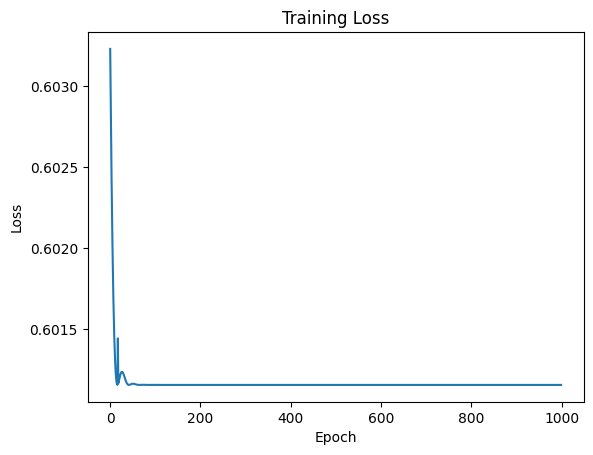

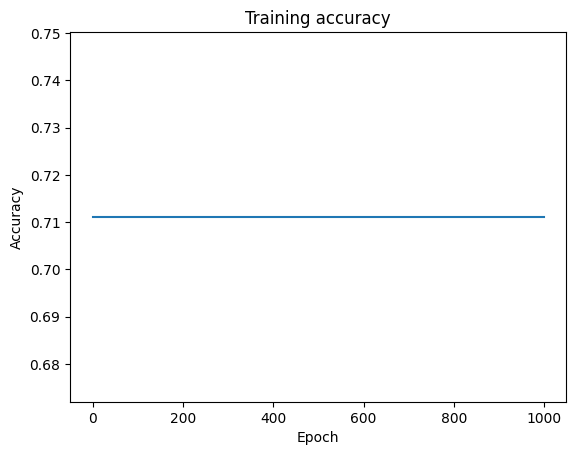

In [183]:
losses = []
accuracies = []
embeddings = []
outputs = []

# Train the model
def train_gcn_model(model, data, y, epochs=1000, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) # , weight_decay=1e-5
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(data.x, data.edge_index)
        loss = bce(outs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print(outs)
        predicted = torch.round(outs)
        #print(predicted)
        acc = (predicted == y).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)


model = GNNClassifier()
train_gcn_model(model, data2, data2.y)

In [31]:
!pip install torchinfo

In [32]:
from torchinfo import summary
print(model)
print(summary(model))

GNNClassifier(
  (gnc1): GATConv(1, 1, heads=1)
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Layer (type:depth-idx)                   Param #
GNNClassifier                            --
├─GATConv: 1-1                           3
│    └─SumAggregation: 2-1               --
│    └─Linear: 2-2                       1
├─Sequential: 1-2                        --
│    └─Linear: 2-3                       2
│    └─Sigmoid: 2-4                      --
Total params: 6
Trainable params: 6
Non-trainable params: 0


# Part 4: Custom Implementation of Layers

[GCNConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html)

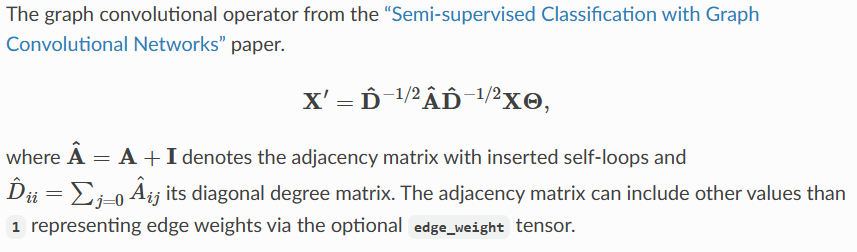

[SimpleConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.SimpleConv.html)

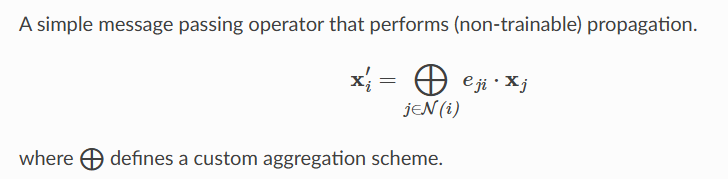

## Implementation of GCNConv

In [189]:
import torch
import numpy as np

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

inputs = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
targets = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)

adj = nx.adjacency_matrix(CountryAdjacencyGraph)
adj_matrix = torch.Tensor(np.array(adj.toarray()))

inputs.shape, targets.shape, adj_matrix.shape

(torch.Size([45, 1]), torch.Size([45, 1]), torch.Size([45, 45]))

In [190]:
# Code adapted from https://medium.com/@jrosseruk/demystifying-gcns-a-step-by-step-guide-to-building-a-graph-convolutional-network-layer-in-pytorch-09bf2e788a51
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter

def normalize_adjacency_matrix(A):
    """
    Compute D^{-1/2} (A + I) D^{-1/2} as done in the paper https://arxiv.org/pdf/1609.02907
    A: adjacency matrix (N x N), torch.Tensor
    Returns normalized adjacency matrix
    """
    N = A.size(0)
    A_hat = A + torch.eye(N)  # Add identity matrix to include node features (torch.eye adds the identity matrix)
    degree = A_hat.sum(1)
    D_inv_sqrt = torch.diag(torch.pow(degree, -0.5))
    A_normalized = D_inv_sqrt @ A_hat @ D_inv_sqrt # @ performs a matrix multiplication https://docs.python.org/3/library/operator.html#mapping-operators-to-functions
    return A_normalized

class CustomGCNConvLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(CustomGCNConvLayer, self).__init__()
        self.weight = Parameter(torch.Tensor(in_features, out_features)) # learnable weights for node features, see https://stackoverflow.com/a/77058113
        self.linear = nn.Linear(in_features, out_features, bias = True)

    def forward(self, features, A):
        """
        H: node features (N x F_in), where N is the number of nodes and F is the dimension of the input features
        A: adjacency matrix (N x N), where N is the number of nodes
        """
        A_normalized = normalize_adjacency_matrix(A)
        #H_prime = A_normalized @ features @ self.weight
        H_prime = A_normalized @ features # aggregate features from neighbouring nodes, based on the adjacency matrix
        return self.linear(H_prime)

In [191]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [192]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define GCN model (uses edge information)
class CustomGCNConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.gnc1 = CustomGCNConvLayer(1, 1)

        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, adj_matrix):
        # embedding
        h = self.gnc1(x, adj_matrix)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

Epoch 1/1000, Loss: 3.5022, Accuracy: 64.44%
Epoch 10/1000, Loss: 2.5644, Accuracy: 57.78%
Epoch 20/1000, Loss: 1.7498, Accuracy: 55.56%
Epoch 30/1000, Loss: 1.2212, Accuracy: 51.11%
Epoch 40/1000, Loss: 0.9904, Accuracy: 40.00%
Epoch 50/1000, Loss: 0.9317, Accuracy: 26.67%
Epoch 60/1000, Loss: 0.9045, Accuracy: 24.44%
Epoch 70/1000, Loss: 0.8751, Accuracy: 26.67%
Epoch 80/1000, Loss: 0.8475, Accuracy: 31.11%
Epoch 90/1000, Loss: 0.8235, Accuracy: 31.11%
Epoch 100/1000, Loss: 0.8017, Accuracy: 31.11%
Epoch 110/1000, Loss: 0.7813, Accuracy: 40.00%
Epoch 120/1000, Loss: 0.7621, Accuracy: 42.22%
Epoch 130/1000, Loss: 0.7442, Accuracy: 44.44%
Epoch 140/1000, Loss: 0.7274, Accuracy: 51.11%
Epoch 150/1000, Loss: 0.7116, Accuracy: 51.11%
Epoch 160/1000, Loss: 0.6968, Accuracy: 57.78%
Epoch 170/1000, Loss: 0.6828, Accuracy: 71.11%
Epoch 180/1000, Loss: 0.6696, Accuracy: 71.11%
Epoch 190/1000, Loss: 0.6572, Accuracy: 71.11%
Epoch 200/1000, Loss: 0.6455, Accuracy: 71.11%
Epoch 210/1000, Loss: 0.

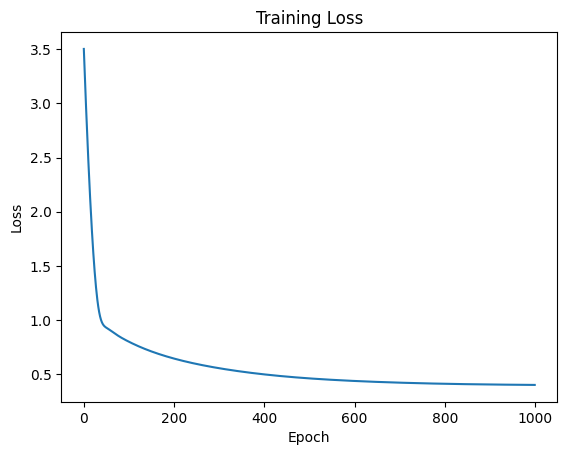

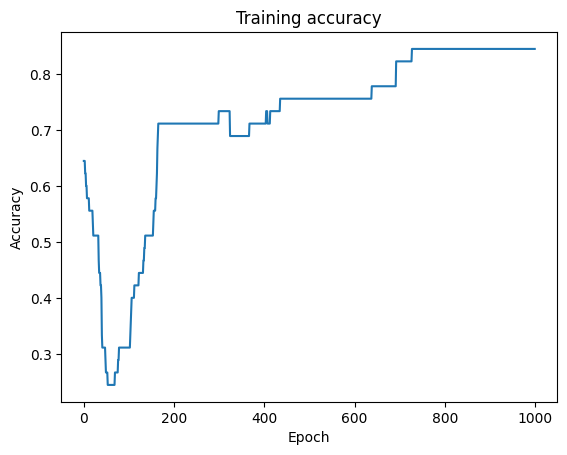

In [193]:
losses = []
accuracies = []
embeddings = []
outputs = []

# Train the model
def train_gcn_model(model, features, adj_matrix, labels, epochs=1000, lr=0.01): #0.006

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(features, adj_matrix)
        loss = bce(outs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outs)
        acc = (predicted == labels).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)

custom_gcn_conv_model = CustomGCNConvClassifier()
train_gcn_model(custom_gcn_conv_model, inputs, adj_matrix, targets)

In [194]:
from torchinfo import summary
print(custom_gcn_conv_model)
print(summary(custom_gcn_conv_model))

CustomGCNConvClassifier(
  (gnc1): CustomGCNConvLayer(
    (linear): Linear(in_features=1, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Layer (type:depth-idx)                   Param #
CustomGCNConvClassifier                  --
├─CustomGCNConvLayer: 1-1                1
│    └─Linear: 2-1                       2
├─Sequential: 1-2                        --
│    └─Linear: 2-2                       2
│    └─Sigmoid: 2-3                      --
Total params: 5
Trainable params: 5
Non-trainable params: 0


## Implementation of SimpleConv

In [195]:
import torch
import numpy as np

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

inputs = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
targets = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)

adj = nx.adjacency_matrix(CountryAdjacencyGraph)
adj_matrix = torch.Tensor(np.array(adj.toarray()))

inputs.shape, targets.shape, adj_matrix.shape

(torch.Size([45, 1]), torch.Size([45, 1]), torch.Size([45, 45]))

In [196]:
# Code adapted from https://medium.com/@jrosseruk/demystifying-gcns-a-step-by-step-guide-to-building-a-graph-convolutional-network-layer-in-pytorch-09bf2e788a51
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter

class CustomSimpleConvLayer(nn.Module):
    def __init__(self):
           super().__init__()

    def forward(self, features, A):
        """
        H: node features (N x F), where N is the number of nodes and F is the dimension of the input features
        A: adjacency matrix (N x N), where N is the number of nodes
        """
       # print(A)
       # print(features)
        H_prime = A @ features
        return H_prime

In [197]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [198]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define GCN model (uses edge information)
class CustomSimpleConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.gnc1 = CustomSimpleConvLayer()

        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, adj_matrix):
        # embedding
        h = self.gnc1(x, adj_matrix)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

Epoch 1/1000, Loss: 5.0236, Accuracy: 28.89%
Epoch 10/1000, Loss: 1.1563, Accuracy: 28.89%
Epoch 20/1000, Loss: 1.1852, Accuracy: 48.89%
Epoch 30/1000, Loss: 1.0028, Accuracy: 28.89%
Epoch 40/1000, Loss: 0.8698, Accuracy: 40.00%
Epoch 50/1000, Loss: 0.8023, Accuracy: 28.89%
Epoch 60/1000, Loss: 0.7661, Accuracy: 26.67%
Epoch 70/1000, Loss: 0.7451, Accuracy: 28.89%
Epoch 80/1000, Loss: 0.7259, Accuracy: 28.89%
Epoch 90/1000, Loss: 0.7055, Accuracy: 28.89%
Epoch 100/1000, Loss: 0.6860, Accuracy: 31.11%
Epoch 110/1000, Loss: 0.6674, Accuracy: 51.11%
Epoch 120/1000, Loss: 0.6493, Accuracy: 66.67%
Epoch 130/1000, Loss: 0.6317, Accuracy: 71.11%
Epoch 140/1000, Loss: 0.6147, Accuracy: 80.00%
Epoch 150/1000, Loss: 0.5984, Accuracy: 82.22%
Epoch 160/1000, Loss: 0.5826, Accuracy: 88.89%
Epoch 170/1000, Loss: 0.5674, Accuracy: 91.11%
Epoch 180/1000, Loss: 0.5528, Accuracy: 91.11%
Epoch 190/1000, Loss: 0.5387, Accuracy: 91.11%
Epoch 200/1000, Loss: 0.5252, Accuracy: 91.11%
Epoch 210/1000, Loss: 0.

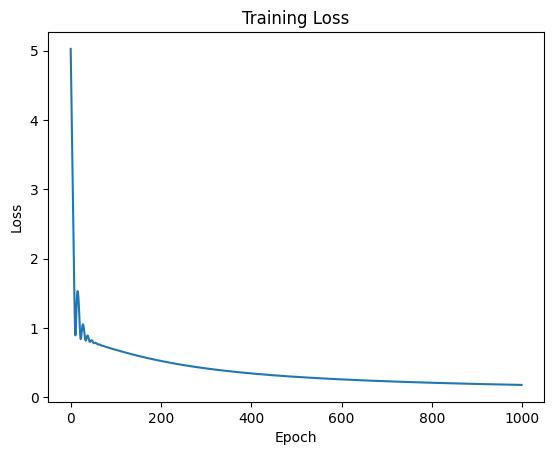

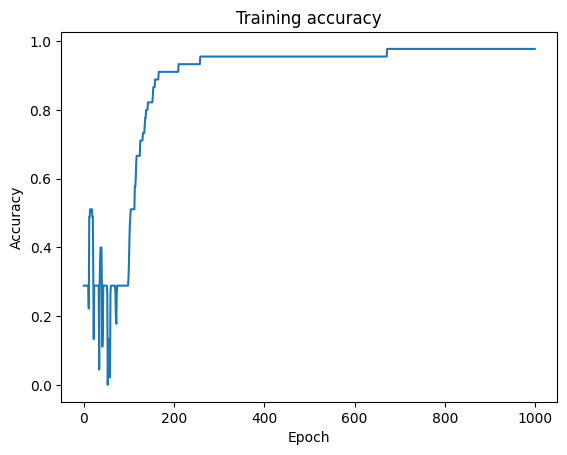

In [199]:
losses = []
accuracies = []
embeddings = []
outputs = []

# Train the model
def train_gcn_model(model, features, adj_matrix, labels, epochs=1000, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(features, adj_matrix)
        loss = bce(outs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outs)
        acc = (predicted == labels).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)

custom_simple_conv_model = CustomSimpleConvClassifier()
train_gcn_model(custom_simple_conv_model, inputs, adj_matrix, targets)

In [200]:
#!pip install torchinfo

In [201]:
from torchinfo import summary
print(custom_simple_conv_model)
print(summary(custom_simple_conv_model))

CustomSimpleConvClassifier(
  (gnc1): CustomSimpleConvLayer()
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Layer (type:depth-idx)                   Param #
CustomSimpleConvClassifier               --
├─CustomSimpleConvLayer: 1-1             --
├─Sequential: 1-2                        --
│    └─Linear: 2-1                       2
│    └─Sigmoid: 2-2                      --
Total params: 2
Trainable params: 2
Non-trainable params: 0


## Implementation of GATConv (Single-Head Attention)

> "In a transformer, the attention mechanism enables the model to assign different attention weights/scores to different tokens in a sequence. This way, the model can give more importance to relevant information, ignore irrelevant information, and effectively capture long-range dependencies in the data" ([Source](https://medium.com/@stefanbschneider/understanding-attention-and-transformers-d84b016cd352))

*Core idea of graph attention: give different attention scores to different nodes in the graph, giving thereby more importance to relevant information (i.e. how important is node j to node i), ignoring irrelevant information, and effectively capturing long-range dependencies in the graph.*




[GATConv](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html)

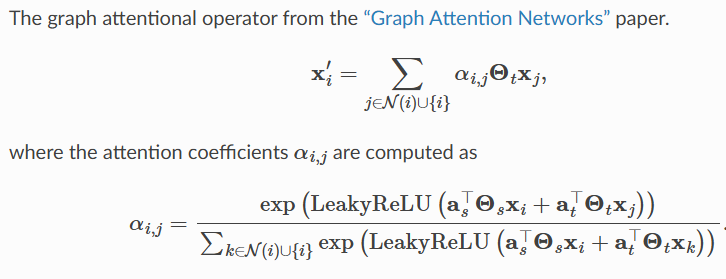

In [202]:
CountryAdjacencyGraph = nx.convert_node_labels_to_integers(G, label_attribute='name')
print(CountryAdjacencyGraph.nodes(data=True))
training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]


[(0, {'population': 2.8, 'label': 0, 'name': 'Albania'}), (1, {'population': 10.1, 'label': 0, 'name': 'Greece'}), (2, {'population': 1.8, 'label': 0, 'name': 'Kosovo'}), (3, {'population': 0.62, 'label': 0, 'name': 'Montenegro'}), (4, {'population': 2.0, 'label': 0, 'name': 'North Macedonia'}), (5, {'population': 0.08, 'label': 0, 'name': 'Andorra'}), (6, {'population': 68.0, 'label': 1, 'name': 'France'}), (7, {'population': 47.6, 'label': 0, 'name': 'Spain'}), (8, {'population': 9.1, 'label': 1, 'name': 'Austria'}), (9, {'population': 10.8, 'label': 0, 'name': 'Czechia'}), (10, {'population': 83.3, 'label': 1, 'name': 'Germany'}), (11, {'population': 9.7, 'label': 0, 'name': 'Hungary'}), (12, {'population': 59.0, 'label': 0, 'name': 'Italy'}), (13, {'population': 0.04, 'label': 0, 'name': 'Liechtenstein'}), (14, {'population': 5.4, 'label': 0, 'name': 'Slovakia'}), (15, {'population': 2.1, 'label': 0, 'name': 'Slovenia'}), (16, {'population': 8.7, 'label': 1, 'name': 'Switzerland'})

In [203]:
import torch
import numpy as np

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

inputs = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
targets = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)

adj = nx.adjacency_matrix(CountryAdjacencyGraph)
adj_matrix = torch.Tensor(np.array(adj.toarray()))

inputs.shape, targets.shape, adj_matrix.shape

(torch.Size([45, 1]), torch.Size([45, 1]), torch.Size([45, 45]))

In [204]:
# https://github.com/AntonioLonga/PytorchGeometricTutorial/blob/main/Tutorial3/Tutorial3.ipynb
import torch
import torch.nn as nn
import torch.nn.functional as F

p_dropout = 0.0
leaky_relu_negative_slope = 0.2

class CustomGATLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.attn = nn.Parameter(torch.empty(size=(2*out_features, 1))) # learnable weights to compute attention score, input = 2*out_features because of the concatenation operation
        self.activation = nn.LeakyReLU(negative_slope=leaky_relu_negative_slope)
        self.softmax = nn.Softmax(dim=1)
        self.weight = nn.Parameter(torch.Tensor(in_features, out_features)) # learnable weights for node features, see https://stackoverflow.com/a/77058113
        self.dropout = nn.Dropout(p_dropout)
        self.out_features = out_features
        self.linear = nn.Linear(in_features, out_features, bias = False)

        self.x_init() # use xavier initialization for the learnable weights

    def x_init(self):
      nn.init.xavier_normal_(self.weight)
      nn.init.xavier_normal_(self.attn)

    def get_attention_scores(self, h_transformed):

        """
        the attention score e_ij is computed as follows:

            e_ij = LeakyReLU(a^T [Wh_i || Wh_j])

            where ^T represents transposition, || denotes the concatenation operation, and a and W are the learnable parameters.

        """

        # Code from https://towardsai.net/p/l/graph-attention-networks-paper-explained-with-illustration-and-pytorch-implementation
        # See also https://github.com/ebrahimpichka/GAT-pt/blob/main/layers.py

        # dot product of all node embeddings and first half the attention vector parameters (corresponding to neighbor messages)
        source_scores = h_transformed @ self.attn[:self.out_features, :]

        # dot product of all node embeddings and second half the attention vector parameters (corresponding to target node)
        target_scores = h_transformed @ self.attn[self.out_features:, :]

        # broadcast add <=> creating a matrix with the sum of both scores in the cells
        e = source_scores + target_scores.mT # transpose the last two dimensions

        return self.activation(e)

    def forward(self, features, adj_mat):
        """
        features: node features (N x F), where N is the number of nodes and F is the dimension of the input features
        adj_mat: adjacency matrix (N x N), where N is the number of nodes
        """
        # linear transformation
        H = features @ self.weight

        # attention scores
        e = self.get_attention_scores(H)

        # masked attention scores: compute attention for neighbouring nodes only <=> take into account graph structure
        connectivity_mask = -9e16 * torch.ones_like(e)
        e = torch.where(adj_mat > 0, e , connectivity_mask) # masked attention scores

        # masked attention weights
        attention_weights = self.softmax(e) # transform the scores in probability summing up to 1 # alternative F.softmax(e, dim=-1)
        attention_weights = self.dropout(attention_weights)

        H_prime = attention_weights @ H

        return self.linear(H_prime)

GAT training

In [205]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [206]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define GCN model (uses edge information)
class CustomGATClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.gal = CustomGATLayer(1, 1)

        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, adj_matrix):
        # embedding
        h = self.gal(x, adj_matrix)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

Epoch 1/1000, Loss: 0.9171, Accuracy: 28.89%
Epoch 10/1000, Loss: 0.8831, Accuracy: 28.89%
Epoch 20/1000, Loss: 0.8478, Accuracy: 28.89%
Epoch 30/1000, Loss: 0.8153, Accuracy: 28.89%
Epoch 40/1000, Loss: 0.7859, Accuracy: 28.89%
Epoch 50/1000, Loss: 0.7596, Accuracy: 28.89%
Epoch 60/1000, Loss: 0.7362, Accuracy: 28.89%
Epoch 70/1000, Loss: 0.7156, Accuracy: 28.89%
Epoch 80/1000, Loss: 0.6976, Accuracy: 28.89%
Epoch 90/1000, Loss: 0.6820, Accuracy: 71.11%
Epoch 100/1000, Loss: 0.6686, Accuracy: 71.11%
Epoch 110/1000, Loss: 0.6571, Accuracy: 71.11%
Epoch 120/1000, Loss: 0.6474, Accuracy: 71.11%
Epoch 130/1000, Loss: 0.6391, Accuracy: 71.11%
Epoch 140/1000, Loss: 0.6322, Accuracy: 71.11%
Epoch 150/1000, Loss: 0.6264, Accuracy: 71.11%
Epoch 160/1000, Loss: 0.6216, Accuracy: 71.11%
Epoch 170/1000, Loss: 0.6176, Accuracy: 71.11%
Epoch 180/1000, Loss: 0.6144, Accuracy: 71.11%
Epoch 190/1000, Loss: 0.6117, Accuracy: 71.11%
Epoch 200/1000, Loss: 0.6095, Accuracy: 71.11%
Epoch 210/1000, Loss: 0.

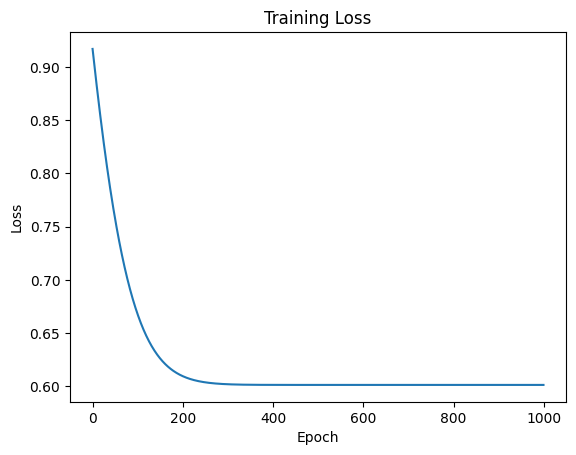

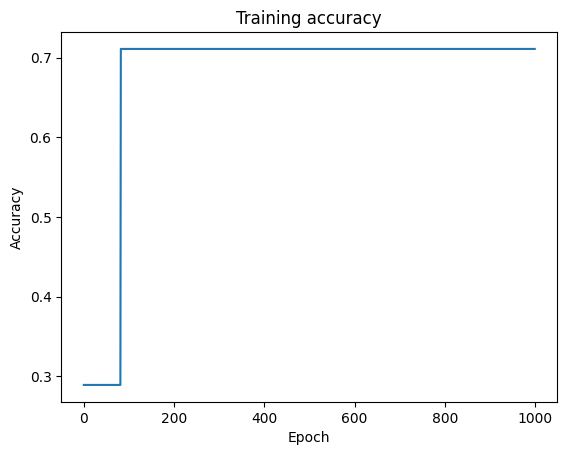

In [207]:
losses = []
accuracies = []
embeddings = []
outputs = []

# Train the model
def train_gcn_model(model, features, adj_matrix, labels, epochs=1000, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(features, adj_matrix)
        loss = bce(outs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outs)
        acc = (predicted == labels).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)

custom_gat_model = CustomGATClassifier()
train_gcn_model(custom_gat_model, inputs, adj_matrix, targets)

In [208]:
from torchinfo import summary
print(custom_gat_model)
print(summary(custom_gat_model))

CustomGATClassifier(
  (gal): CustomGATLayer(
    (activation): LeakyReLU(negative_slope=0.2)
    (softmax): Softmax(dim=1)
    (dropout): Dropout(p=0.0, inplace=False)
    (linear): Linear(in_features=1, out_features=1, bias=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Layer (type:depth-idx)                   Param #
CustomGATClassifier                      --
├─CustomGATLayer: 1-1                    3
│    └─LeakyReLU: 2-1                    --
│    └─Softmax: 2-2                      --
│    └─Dropout: 2-3                      --
│    └─Linear: 2-4                       1
├─Sequential: 1-2                        --
│    └─Linear: 2-5                       2
│    └─Sigmoid: 2-6                      --
Total params: 6
Trainable params: 6
Non-trainable params: 0


## GAT explanation of the substeps

In [53]:
# torch empty: tensor filled with uninitialized data
torch.empty(size=(3, 3))

tensor([[2.4953e-24, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.4013e-45, 0.0000e+00],
        [1.3593e-43, 0.0000e+00, 2.4626e-24]])

In [54]:
# When a tensor is wrapped with torch.nn.Parameter, it automatically becomes a part of the model's parameters, and thus it will be updated when backpropagation is applied during training
# https://www.geeksforgeeks.org/deep-learning/understanding-torchnnparameter/
W = nn.Parameter(torch.empty(size=(3, 3)))
W, W.shape

(Parameter containing:
 tensor([[2.4869e-24, 0.0000e+00, 8.2373e-16],
         [4.3387e-41, 8.9683e-44, 0.0000e+00],
         [1.3452e-43, 0.0000e+00, 2.7895e-24]], requires_grad=True),
 torch.Size([3, 3]))

In [55]:
W1 = nn.Parameter(torch.Tensor(1, 1))
t = inputs @ W1
t, t.shape

(tensor([[2.3065e-15],
         [8.3198e-15],
         [1.4827e-15],
         [5.1072e-16],
         [1.6475e-15],
         [6.5899e-17],
         [5.6014e-14],
         [3.9210e-14],
         [7.4960e-15],
         [8.8964e-15],
         [6.8618e-14],
         [7.9903e-15],
         [4.8601e-14],
         [3.2950e-17],
         [4.4482e-15],
         [1.7299e-15],
         [7.1665e-15],
         [7.5784e-15],
         [1.5651e-15],
         [2.1417e-15],
         [3.0890e-14],
         [1.1812e-13],
         [2.8831e-14],
         [9.5554e-15],
         [5.5191e-16],
         [1.4663e-14],
         [2.6360e-15],
         [3.2126e-15],
         [5.4367e-15],
         [5.3543e-15],
         [1.5651e-14],
         [7.0018e-14],
         [4.8601e-15],
         [1.0709e-15],
         [4.5306e-15],
         [4.5306e-15],
         [8.7317e-15],
         [3.2950e-17],
         [2.4712e-17],
         [4.2011e-15],
         [5.6179e-14],
         [2.4712e-17],
         [6.5899e-19],
         [2

In [56]:
lin = nn.Linear(1, 1, bias=False) # multiplication by weight is equivalent to linear transformation w/without bias
t2 = lin(inputs)
t2, t2.shape

(tensor([[-4.5625e-01],
         [-1.6457e+00],
         [-2.9330e-01],
         [-1.0103e-01],
         [-3.2589e-01],
         [-1.3036e-02],
         [-1.1080e+01],
         [-7.7562e+00],
         [-1.4828e+00],
         [-1.7598e+00],
         [-1.3573e+01],
         [-1.5806e+00],
         [-9.6137e+00],
         [-6.5178e-03],
         [-8.7990e-01],
         [-3.4218e-01],
         [-1.4176e+00],
         [-1.4991e+00],
         [-3.0959e-01],
         [-4.2366e-01],
         [-6.1104e+00],
         [-2.3366e+01],
         [-5.7031e+00],
         [-1.8902e+00],
         [-1.0917e-01],
         [-2.9004e+00],
         [-5.2142e-01],
         [-6.3548e-01],
         [-1.0754e+00],
         [-1.0591e+00],
         [-3.0959e+00],
         [-1.3850e+01],
         [-9.6137e-01],
         [-2.1183e-01],
         [-8.9620e-01],
         [-8.9620e-01],
         [-1.7272e+00],
         [-6.5178e-03],
         [-4.8883e-03],
         [-8.3102e-01],
         [-1.1113e+01],
         [-4.888

In [57]:
# Matrix transpose: rows become columns and vice versa
import torch

my_tensor = torch.tensor([[0, 1, 2], [3, 4, 5],
                          [6, 7, 8], [9, 10, 11]])
my_tensor, my_tensor.shape, my_tensor.mT, my_tensor.mT.shape, my_tensor.transpose(0, 1), my_tensor.transpose(0, 1).shape #(0, 1) => swap dimensions 0 and 1

(tensor([[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]]),
 torch.Size([4, 3]),
 tensor([[ 0,  3,  6,  9],
         [ 1,  4,  7, 10],
         [ 2,  5,  8, 11]]),
 torch.Size([3, 4]),
 tensor([[ 0,  3,  6,  9],
         [ 1,  4,  7, 10],
         [ 2,  5,  8, 11]]),
 torch.Size([3, 4]))

In [58]:
# torch.one_likes: create a tensor filled with ones, with the same size as the input
u = torch.empty(2,3)
u, torch.ones_like(u)

(tensor([[0.0000e+00, 0.0000e+00, 7.1746e-43],
         [0.0000e+00, 4.4435e-42, 0.0000e+00]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.]]))

In [59]:
# torch.where: selecting elements based on condition
adj = torch.Tensor([[1, 1], [0, 0]])
f = torch.empty(2,2)
print(f)
connectivity_mask = -9e16 * torch.ones_like(f)

f = torch.where(adj > 0, f , connectivity_mask)
adj, connectivity_mask,  f

tensor([[8.2374e-16, 4.3387e-41],
        [9.5675e-25, 0.0000e+00]])


(tensor([[1., 1.],
         [0., 0.]]),
 tensor([[-9.0000e+16, -9.0000e+16],
         [-9.0000e+16, -9.0000e+16]]),
 tensor([[ 8.2374e-16,  4.3387e-41],
         [-9.0000e+16, -9.0000e+16]]))

In [60]:
# repeat: repeat a tensor n times
n_nodes = 3
u = torch.Tensor([[[1, 1, 1]], [[2, 2, 2]], [[3, 3, 3]]])
v = u.repeat (n_nodes, 1, 1)
u, u.shape, v, v.shape

(tensor([[[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]]]),
 torch.Size([3, 1, 3]),
 tensor([[[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]],
 
         [[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]],
 
         [[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]]]),
 torch.Size([9, 1, 3]))

In [61]:
# repeat: repeat a tensor n times, choose the dimension along which the repetition should happen
n_nodes = 3
e = torch.Tensor(torch.Tensor([[[1, 1, 1]], [[2, 2, 2]], [[3, 3, 3]]]))
f = e.repeat_interleave (n_nodes, dim=0) # dim = 0 => level; dim = 1 => row, dim = 2 => column, it seems
e, e.shape, f, f.shape

(tensor([[[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]]]),
 torch.Size([3, 1, 3]),
 tensor([[[1., 1., 1.]],
 
         [[1., 1., 1.]],
 
         [[1., 1., 1.]],
 
         [[2., 2., 2.]],
 
         [[2., 2., 2.]],
 
         [[2., 2., 2.]],
 
         [[3., 3., 3.]],
 
         [[3., 3., 3.]],
 
         [[3., 3., 3.]]]),
 torch.Size([9, 1, 3]))

In [62]:
g = torch.cat([f, v], dim=-1) # -1 is last dimension
g, g.shape

(tensor([[[1., 1., 1., 1., 1., 1.]],
 
         [[1., 1., 1., 2., 2., 2.]],
 
         [[1., 1., 1., 3., 3., 3.]],
 
         [[2., 2., 2., 1., 1., 1.]],
 
         [[2., 2., 2., 2., 2., 2.]],
 
         [[2., 2., 2., 3., 3., 3.]],
 
         [[3., 3., 3., 1., 1., 1.]],
 
         [[3., 3., 3., 2., 2., 2.]],
 
         [[3., 3., 3., 3., 3., 3.]]]),
 torch.Size([9, 1, 6]))

In [63]:
n_nodes = 3
u = torch.Tensor(torch.Tensor([[1, 1, 1], [2, 2, 2], [3, 3, 3]]))
u.shape

torch.Size([3, 3])

In [64]:
attn = nn.Parameter(torch.empty(size=(2*n_nodes, 1)).fill_(10))
attn, attn.shape

(Parameter containing:
 tensor([[10.],
         [10.],
         [10.],
         [10.],
         [10.],
         [10.]], requires_grad=True),
 torch.Size([6, 1]))

In [65]:
s = u @ attn[:n_nodes, :]
s

tensor([[30.],
        [60.],
        [90.]], grad_fn=<MmBackward0>)

In [66]:
t = u @ attn[n_nodes:, :]
t

tensor([[30.],
        [60.],
        [90.]], grad_fn=<MmBackward0>)

In [67]:
t, t.T, t.mT

(tensor([[30.],
         [60.],
         [90.]], grad_fn=<MmBackward0>),
 tensor([[30., 60., 90.]], grad_fn=<PermuteBackward0>),
 tensor([[30., 60., 90.]], grad_fn=<TransposeBackward0>))

In [68]:
a = s + t.T
a

tensor([[ 60.,  90., 120.],
        [ 90., 120., 150.],
        [120., 150., 180.]], grad_fn=<AddBackward0>)

In [69]:
n_nodes = 6
n_heads = 4
n_hidden = 2

import torch
u = torch.empty(size=(n_heads, n_nodes, n_hidden))
v = torch.empty(size=(n_heads, n_hidden, 1))

w = u @ v

print(u.shape, v.shape, w.shape)

torch.Size([4, 6, 2]) torch.Size([4, 2, 1]) torch.Size([4, 6, 1])


In [70]:
# softmax
input = torch.randn(2, 2)
m = nn.Softmax(dim = 0)
output = m(input)
input, output

(tensor([[-0.7502, -1.3205],
         [ 0.1500,  0.6167]]),
 tensor([[0.2890, 0.1260],
         [0.7110, 0.8740]]))

In [71]:
# dropout
input = torch.randn(3 , 2)
m = nn.Dropout(p=0.6)
output = m(input)
input, output

(tensor([[ 1.1064, -0.1959],
         [-0.8222,  1.4946],
         [ 0.0509,  0.5722]]),
 tensor([[ 0.0000, -0.4896],
         [-2.0554,  0.0000],
         [ 0.0000,  1.4305]]))

In [119]:
x = torch.arange(2*3*4*5).view(2, 3, 4, 5)
print(x.shape, x)

y1 = x.transpose(-2, -1) # swap dimension -1 (= last dimension) and dimension -2 (= final last dimension)
print(y1.shape, y1)
y2 = x.permute(0, 1, 3, 2) # change the order of the dimensions (0, 1, 2, 3 => 0, 2, 3, 2)
print(y2.shape, y2)

print((y1 == y2).all())

torch.Size([2, 3, 4, 5]) tensor([[[[  0,   1,   2,   3,   4],
          [  5,   6,   7,   8,   9],
          [ 10,  11,  12,  13,  14],
          [ 15,  16,  17,  18,  19]],

         [[ 20,  21,  22,  23,  24],
          [ 25,  26,  27,  28,  29],
          [ 30,  31,  32,  33,  34],
          [ 35,  36,  37,  38,  39]],

         [[ 40,  41,  42,  43,  44],
          [ 45,  46,  47,  48,  49],
          [ 50,  51,  52,  53,  54],
          [ 55,  56,  57,  58,  59]]],


        [[[ 60,  61,  62,  63,  64],
          [ 65,  66,  67,  68,  69],
          [ 70,  71,  72,  73,  74],
          [ 75,  76,  77,  78,  79]],

         [[ 80,  81,  82,  83,  84],
          [ 85,  86,  87,  88,  89],
          [ 90,  91,  92,  93,  94],
          [ 95,  96,  97,  98,  99]],

         [[100, 101, 102, 103, 104],
          [105, 106, 107, 108, 109],
          [110, 111, 112, 113, 114],
          [115, 116, 117, 118, 119]]]])
torch.Size([2, 3, 5, 4]) tensor([[[[  0,   5,  10,  15],
          [  1,

## Implementation of GATConv (Multi-Head Attention)

In [109]:
CountryAdjacencyGraph = nx.convert_node_labels_to_integers(G, label_attribute='name')
print(CountryAdjacencyGraph.nodes(data=True))
training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]


[(0, {'population': 2.8, 'label': 0, 'name': 'Albania'}), (1, {'population': 10.1, 'label': 0, 'name': 'Greece'}), (2, {'population': 1.8, 'label': 0, 'name': 'Kosovo'}), (3, {'population': 0.62, 'label': 0, 'name': 'Montenegro'}), (4, {'population': 2.0, 'label': 0, 'name': 'North Macedonia'}), (5, {'population': 0.08, 'label': 0, 'name': 'Andorra'}), (6, {'population': 68.0, 'label': 1, 'name': 'France'}), (7, {'population': 47.6, 'label': 0, 'name': 'Spain'}), (8, {'population': 9.1, 'label': 1, 'name': 'Austria'}), (9, {'population': 10.8, 'label': 0, 'name': 'Czechia'}), (10, {'population': 83.3, 'label': 1, 'name': 'Germany'}), (11, {'population': 9.7, 'label': 0, 'name': 'Hungary'}), (12, {'population': 59.0, 'label': 0, 'name': 'Italy'}), (13, {'population': 0.04, 'label': 0, 'name': 'Liechtenstein'}), (14, {'population': 5.4, 'label': 0, 'name': 'Slovakia'}), (15, {'population': 2.1, 'label': 0, 'name': 'Slovenia'}), (16, {'population': 8.7, 'label': 1, 'name': 'Switzerland'})

In [110]:
import torch
import numpy as np

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

inputs = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
targets = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)

adj = nx.adjacency_matrix(CountryAdjacencyGraph)
adj_matrix = torch.Tensor(np.array(adj.toarray()))

inputs.shape, targets.shape, adj_matrix.shape

(torch.Size([45, 1]), torch.Size([45, 1]), torch.Size([45, 45]))

In [111]:
# https://github.com/AntonioLonga/PytorchGeometricTutorial/blob/main/Tutorial3/Tutorial3.ipynb
import torch
import torch.nn as nn
import torch.nn.functional as F

p_dropout = 0.0
leaky_relu_negative_slope = 0.2

class CustomGATLayerMultiHead(nn.Module):
    def __init__(self, in_features, out_features, n_heads, concat=True):
        super().__init__()
        self.n_heads = n_heads
        self.concat = concat
        self.softmax = nn.Softmax(dim=1)
        self.dropout = nn.Dropout(p_dropout)
        # https://github.com/ebrahimpichka/GAT-pt/blob/main/layers.py
        if concat: # concatenating the attention heads
            self.out_features = out_features # number of output features per node
            assert out_features % n_heads == 0 # ensure that out_features is a multiple of n_heads
            self.n_features_per_head = out_features // n_heads
        else: # averaging output over the attention heads (used in the main paper)
            self.n_features_per_head = out_features

        self.attn = nn.Parameter(torch.empty(size=(n_heads, 2 * self.n_features_per_head, 1))) # learnable weights to compute attention score, input = 2*out_features because of the concatenation operation
        self.weight = nn.Parameter(torch.Tensor(in_features, self.n_features_per_head * n_heads)) # learnable weights for node features, see https://stackoverflow.com/a/77058113
        self.activation = nn.LeakyReLU(negative_slope=leaky_relu_negative_slope)
        self.linear = nn.Linear(in_features, out_features, bias = False)

        self.x_init() # use xavier initialization for the learnable weights

    def x_init(self):
      nn.init.xavier_normal_(self.weight)
      nn.init.xavier_normal_(self.attn)

    def get_attention_scores(self, h_transformed):

        """
        the attention score e_ij is computed as follows:

            e_ij = LeakyReLU(a^T [Wh_i || Wh_j])

            where ^T represents transposition, || denotes the concatenation operation, and a and W are the learnable parameters.

        """

        # Code from https://towardsai.net/p/l/graph-attention-networks-paper-explained-with-illustration-and-pytorch-implementation
        # See also https://github.com/ebrahimpichka/GAT-pt/blob/main/layers.py

        # dot product of all node embeddings and first half the attention vector parameters (corresponding to neighbor messages)
        # output shape (n_heads, n_nodes, n_features_per_head) * (n_heads, n_features_per_head, 1) => (n_heads, n_nodes, 1)
        source_scores = h_transformed @ self.attn[:, :self.n_features_per_head, :]

        # dot product of all node embeddings and second half the attention vector parameters (corresponding to target node)
        # output shape (n_heads, n_nodes, n_features_per_head) * (n_heads, n_features_per_head, 1) => (n_heads, n_nodes, 1)
        target_scores = h_transformed @ self.attn[:, :self.n_features_per_head, :]

        # broadcast add <=> creating a matrix with the sum of both scores in the cells
        # (n_heads, n_nodes, 1) + (n_heads, 1, n_nodes) = (n_heads, n_nodes, n_nodes)
        e = source_scores + target_scores.mT # transpose the last two dimensions

        return self.activation(e)

    def forward(self, features, adj_mat):
        """
        features: node features (N x F), where N is the number of nodes and F is the dimension of the input features
        adj_mat: adjacency matrix (N x N), where N is the number of nodes
        """

        n_nodes = features.shape[0]

        # linear transformation
        # output shape (n_nodes, n_features) * (n_features * n_features) => (n_nodes, n_features)
        H = features @ self.weight

        # output shape (n_nodes, n_heads, n_features_per_head)
        g = H.view(n_nodes, self.n_heads, self.n_features_per_head)
        #print ("a-", g.shape)

        # output shape (n_heads, n_nodes, n_features_per_head)
        g = g.permute(1, 0, 2)
        #print("b-",g.shape)

        # attention scores
        # output shape (n_heads, n_nodes, n_nodes)
        e = self.get_attention_scores(g)
        #print("c-",e.shape)

        # masked attention scores: compute attention for neighbouring nodes only <=> take into account graph structure
        connectivity_mask = -9e16 * torch.ones_like(e)
        e = torch.where(adj_mat > 0, e , connectivity_mask) # masked attention scores
        #print("d-", e.shape)

        # masked attention weights
        attention_weights = self.softmax(e) # transform the scores in probability summing up to 1 # alternative F.softmax(e, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # output shape (n_heads, n_nodes, n_nodes) * (n_nodes, n_features) => (n_heads, n_nodes, n_features)
        H_prime = attention_weights @ H
        #print("e-", H_prime.shape)

        # concatenating/averaging the attention heads
        # output shape (n_nodes, out_features)
        if self.concat:
            H_prime = H_prime.permute(1, 0, 2).contiguous().view(n_nodes, self.out_features)
            #print("f-", H_prime.shape)
        else:
            H_prime = H_prime.mean(dim=0)
            #print("g-", H_prime.shape)

        return self.linear(H_prime)

GAT training

In [112]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [113]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define GCN model (uses edge information)
class CustomGATClassifierMultiHead(nn.Module):
    def __init__(self):
        super().__init__()

        self.gal = CustomGATLayerMultiHead(1, 1, 1)

        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, adj_matrix):
        # embedding
        h = self.gal(x, adj_matrix)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

Epoch 1/1000, Loss: 0.7231, Accuracy: 71.11%
Epoch 10/1000, Loss: 0.6044, Accuracy: 71.11%
Epoch 20/1000, Loss: 0.6025, Accuracy: 71.11%
Epoch 30/1000, Loss: 0.6016, Accuracy: 71.11%
Epoch 40/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 50/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 60/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 70/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 80/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 90/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 100/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 110/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 120/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 130/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 140/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 150/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 160/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 170/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 180/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 190/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 200/1000, Loss: 0.6012, Accuracy: 71.11%
Epoch 210/1000, Loss: 0.

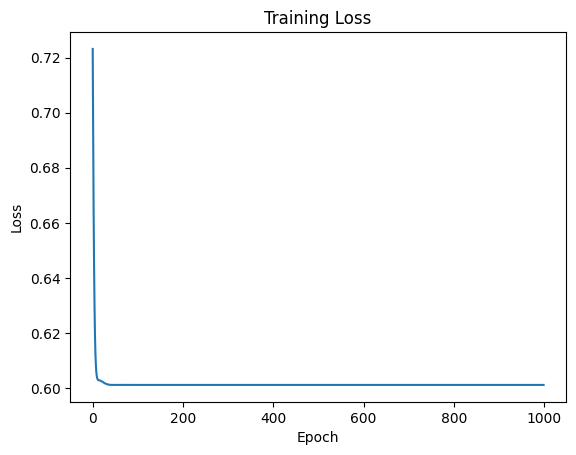

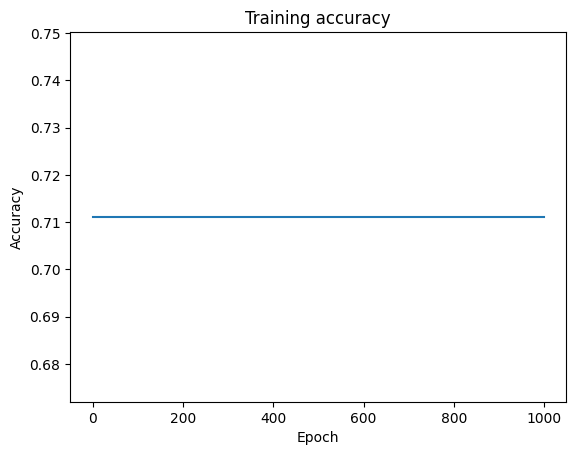

In [114]:
losses = []
accuracies = []
embeddings = []
outputs = []

# Train the model
def train_gcn_model(model, features, adj_matrix, labels, epochs=1000, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(features, adj_matrix)
        loss = bce(outs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outs)
        acc = (predicted == labels).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)

custom_gat_model_multihead = CustomGATClassifierMultiHead()
train_gcn_model(custom_gat_model_multihead, inputs, adj_matrix, targets)

In [115]:
!pip install torchinfo

In [116]:
from torchinfo import summary
print(custom_gat_model_multihead)
print(summary(custom_gat_model_multihead))

CustomGATClassifierMultiHead(
  (gal): CustomGATLayerMultiHead(
    (softmax): Softmax(dim=1)
    (dropout): Dropout(p=0.0, inplace=False)
    (activation): LeakyReLU(negative_slope=0.2)
    (linear): Linear(in_features=1, out_features=1, bias=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Layer (type:depth-idx)                   Param #
CustomGATClassifierMultiHead             --
├─CustomGATLayerMultiHead: 1-1           3
│    └─Softmax: 2-1                      --
│    └─Dropout: 2-2                      --
│    └─LeakyReLU: 2-3                    --
│    └─Linear: 2-4                       1
├─Sequential: 1-2                        --
│    └─Linear: 2-5                       2
│    └─Sigmoid: 2-6                      --
Total params: 6
Trainable params: 6
Non-trainable params: 0


# Project work



*   EX01: Complex tensor operations: Compute the scatter_add and the scatter_mean for two tensors
*   EX02: Modify the code above to implement gat2conv. Use a single-head attention only. For a simple comparison of the main  difference between the two layers, see [here]( https://nn.labml.ai/graphs/gatv2/index.html). For the scientific articles introducing the two architectures, see the [gatconv paper](https://arxiv.org/pdf/1710.10903) and the [gat2conv paper](https://arxiv.org/abs/2105.14491).



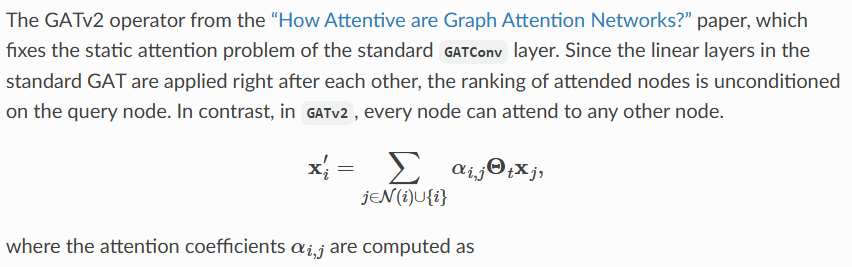


*   EX03: Implement the GraphConv operator from Pytorch Geometric and compare your results with the [off-the-self](https://pytorch-geometric.readthedocs.io/en/2.5.3/generated/torch_geometric.nn.conv.GraphConv.html) implementation

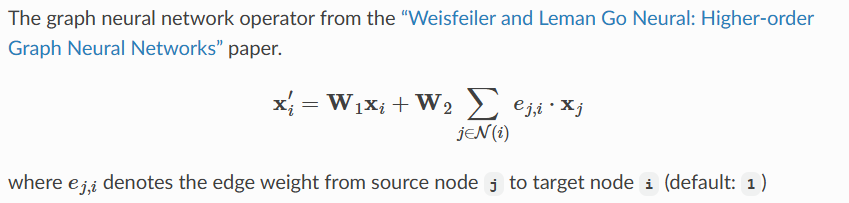

In [ ]:
!pip install torch-scatter

In [ ]:
# https://pytorch-scatter.readthedocs.io/en/1.4.0/functions/add.html
from torch_scatter import scatter_add, scatter_mean

src = torch.Tensor([[2, 0, 1, 4, 3], [0, 2, 1, 3, 4]])
index = torch.tensor([[4, 5, 4, 2, 3], [0, 0, 2, 2, 1]])
out = src.new_zeros((2, 6))

out = scatter_add(src, index, out=out)

print(out)


*   EX04: Think about which GNN block(s) you would need to generate node embeddings for your project work (write down the requirements only)